# 3. Customer Segmentation with K-Means Clustering ✅

Advanced customer segmentation using multiple features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')

import sys
import sys
import os

sys.path.append(os.path.abspath('../src'))
from clustering import (
    prepare_features_for_clustering,
    find_optimal_k,
    fit_customer_clusters,
    visualize_clusters
)
import joblib

In [3]:
# Load user features from preprocessing
features = pd.read_csv('data/processed/user_features.csv')
print(f'Loaded {len(features)} users')
print(features.head())
print('\nFeature stats:')
print(features.describe())

Loaded 206209 users
   user_id  num_orders  total_items  num_reorders  reorder_rate
0        1          10           59            59         0.695
1        2          14          195           195         0.477
2        3          12           88            88         0.625
3        4           5           18            18         0.056
4        5           4           37            37         0.378

Feature stats:
             user_id     num_orders    total_items   num_reorders  \
count  206209.000000  206209.000000  206209.000000  206209.000000   
mean   103105.000000      15.590367     157.289396     157.289396   
std     59527.555167      16.654774     204.208233     204.208233   
min         1.000000       3.000000       3.000000       3.000000   
25%     51553.000000       5.000000      39.000000      39.000000   
50%    103105.000000       9.000000      83.000000      83.000000   
75%    154657.000000      19.000000     188.000000     188.000000   
max    206209.000000      99

In [5]:
# Step 1: Prepare and scale features
X_scaled, feature_cols, scaler = prepare_features_for_clustering(features)

print(f'Scaled features shape: {X_scaled.shape}')
print(f'Features: {feature_cols}')

# Create models folder if not exists
import os
os.makedirs('models', exist_ok=True)

# Save scaler
import joblib
joblib.dump(scaler, 'models/feature_scaler.joblib')

print('✅ Scaler saved')

Scaled features shape: (206209, 4)
Features: ['num_orders', 'total_items', 'num_reorders', 'reorder_rate']
✅ Scaler saved


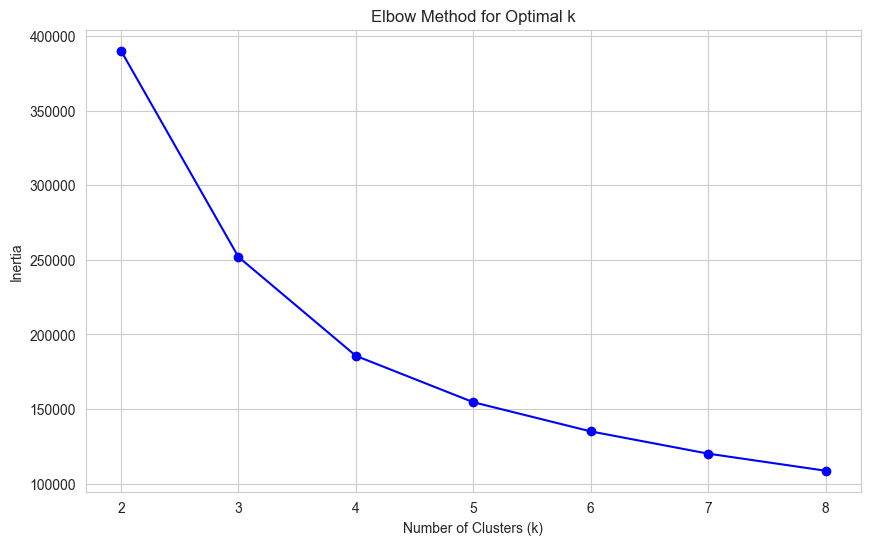


🎯 Using k=5 clusters


In [6]:
# Step 2: Find optimal number of clusters
optimal_k = find_optimal_k(X_scaled, max_k=8)
print(f'\n🎯 Using k={optimal_k} clusters')

In [7]:
# Step 3: Fit clusters
clusters = fit_customer_clusters(X_scaled, n_clusters=optimal_k)
features['cluster'] = clusters

print('\nCluster distribution:')
print(features['cluster'].value_counts().sort_index())
print('\nCluster proportions:')
print(features['cluster'].value_counts(normalize=True).round(3))

✅ KMeans model saved to models/kmeans_clusters.joblib

Cluster distribution:
cluster
0    37824
1    74481
2     4934
3    16026
4    72944
Name: count, dtype: int64

Cluster proportions:
cluster
1    0.361
4    0.354
0    0.183
3    0.078
2    0.024
Name: proportion, dtype: float64


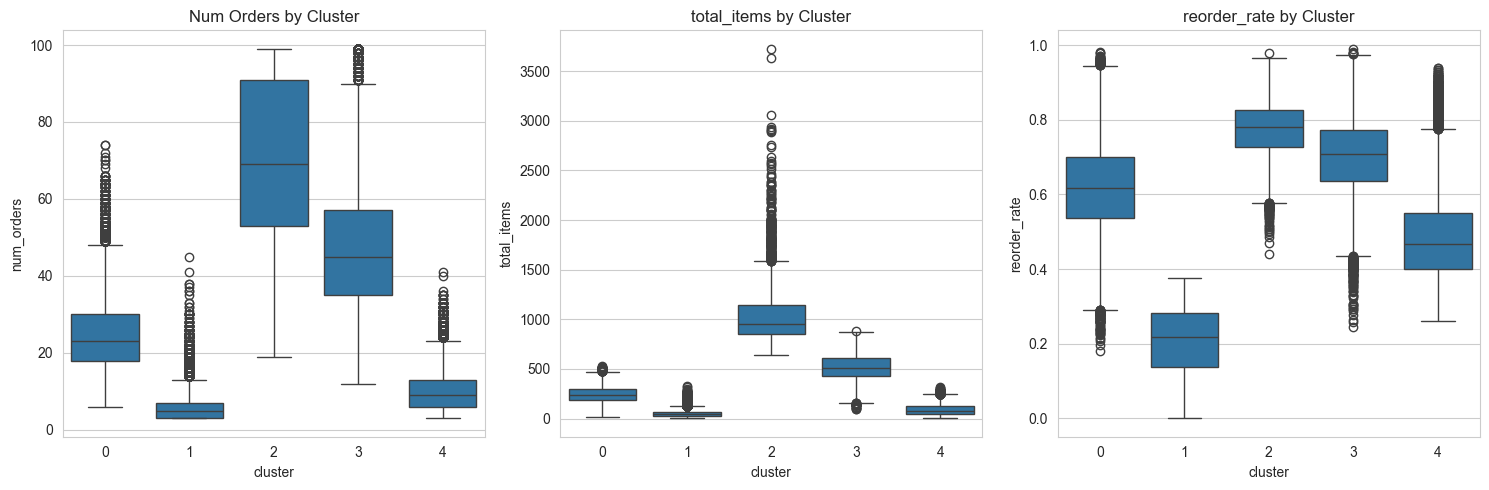


Cluster Centers:
   num_orders  total_items  num_reorders  reorder_rate
0       24.87       240.69        240.69          0.62
1        5.58        48.47         48.47          0.21
2       70.46      1032.28       1032.28          0.77
3       47.81       515.89        515.89          0.70
4       10.18        86.80         86.80          0.49


In [12]:
# Step 4: Visualize results
visualize_clusters(features, clusters)

# Load cluster centers
kmeans = joblib.load('models/kmeans_clusters.joblib')
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_), 
    columns=feature_cols
)
print('\nCluster Centers:')
print(centers.round(2))

In [13]:
# Save clustered users
features.to_csv('data/processed/clustered_users.csv', index=False)
print('✅ Clustered users saved to data/processed/clustered_users.csv')

# Cluster profile summary
print('\n=== CUSTOMER SEGMENTS ===')
for i in range(optimal_k):
    cluster_users = features[features['cluster'] == i]
    print(f'\nCluster {i}: {len(cluster_users):,} users ({len(cluster_users)/len(features)*100:.1f}%)')
    print(f'  Avg orders: {cluster_users["num_orders"].mean():.1f}')
    print(f'  Avg items: {cluster_users["total_items"].mean():.0f}')
    print(f'  Reorder rate: {cluster_users["reorder_rate"].mean():.1%}')

✅ Clustered users saved to data/processed/clustered_users.csv

=== CUSTOMER SEGMENTS ===

Cluster 0: 37,824 users (18.3%)
  Avg orders: 24.9
  Avg items: 241
  Reorder rate: 61.8%

Cluster 1: 74,481 users (36.1%)
  Avg orders: 5.6
  Avg items: 48
  Reorder rate: 20.5%

Cluster 2: 4,934 users (2.4%)
  Avg orders: 70.5
  Avg items: 1033
  Reorder rate: 77.2%

Cluster 3: 16,026 users (7.8%)
  Avg orders: 47.9
  Avg items: 516
  Reorder rate: 70.2%

Cluster 4: 72,944 users (35.4%)
  Avg orders: 10.2
  Avg items: 87
  Reorder rate: 48.5%


## Phase 3 Summary ✅

**Saved:**
- `models/kmeans_clusters.joblib`
- `models/feature_scaler.joblib`
- `results/elbow_plot.png`
- `results/cluster_visualization.png`
- `data/processed/clustered_users.csv`

**5 Customer Segments Ready!** 👥 → Next: Association Rules (Notebook 4)